In [1]:
!pip install opencv_python
!pip install natsort

fish: Unknown command: pip
fish: 
pip install opencv_python
^~^
fish: Unknown command: pip
fish: 
pip install natsort
^~^


In [2]:
import cv2
import pickle
from natsort import natsorted
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression


In [3]:
data_fname = 'data.pickle'

In [4]:
with open(data_fname, 'rb') as handle:
    data = pickle.load(handle)

In [5]:
natsorted(data.keys())

['0.pickle',
 '1.pickle',
 '2.pickle',
 '3.pickle',
 '4.pickle',
 '5.pickle',
 '6.pickle',
 '7.pickle',
 '8.pickle',
 '9.pickle',
 '10.pickle',
 '11.pickle',
 '12.pickle',
 '13.pickle',
 '14.pickle',
 '15.pickle',
 '16.pickle',
 '17.pickle',
 '18.pickle',
 '19.pickle',
 '20.pickle',
 '21.pickle',
 '22.pickle',
 '23.pickle',
 '24.pickle',
 '25.pickle',
 '26.pickle',
 '27.pickle',
 '28.pickle',
 '29.pickle',
 '30.pickle',
 '31.pickle',
 '32.pickle',
 '33.pickle',
 '34.pickle',
 '35.pickle',
 '36.pickle',
 '37.pickle']

# Визуализация

Можно заметить, что распознанные границы объектов не всегда четко определены:

- присутствует перспектива на изображении, из-за чего силуэт полок бывает не строго горизонтальный, а изменяет направление на одном фото:
    - примеры изображений: 0, 3, 5, 17, 18, 22, 25, 30, 33;
- изображение может не охватывать целиком весь стилаж:
    - примеры изображений: 4, 11;
- встречаются наслоения границ объектов друг на друга:
    - примеры изображений: 0, 9, 21, 29;
- встречаются явно ошибочные хаотично-распознанные изображения:
    - примеры изображений: 7;
- объекты, которые вплотную располагаются скорее всего находятся на одной полке, но в 2 ряда:
    - примеры изображений: 8, 19, 21, 27, 30, 34, 35, 36;
- есть ситуации, когда объекты с разных рядов распознаются как один:
    - примеры изображений: 20;
- на полках могут встречаться пропуски товара:
    - примеры изображений: 12, 13, 26, 28.


In [6]:
id = 2

fname = f'{id}.pickle'

img_size = data[fname]['img_size']
bboxes = data[fname]['bboxes']

In [7]:
img = np.zeros(img_size, dtype=np.uint8)
img.fill(255)

for x1, y1, x2, y2 in bboxes:
    img = cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 0), 2)

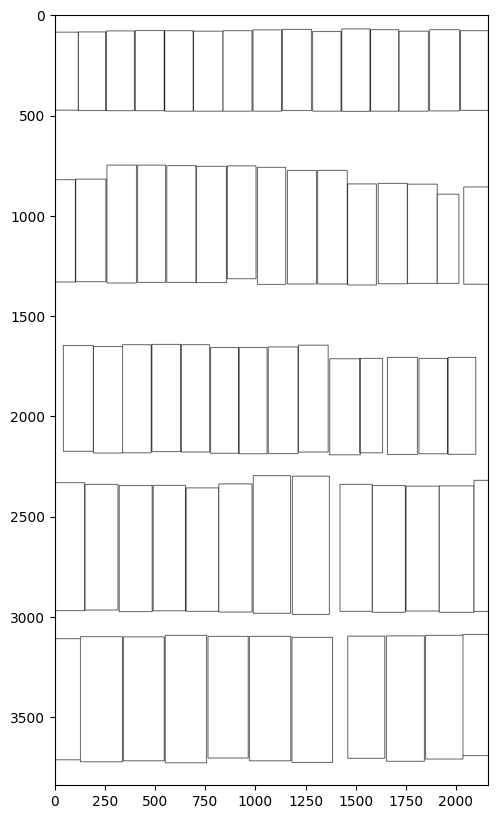

In [8]:
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.show()

# Задание

Написать функцию divide_by_shelfs, принимающую на вход bboxes, img_size и возвращающую для каждого прямоугольника из bboxes номер полки. Нумерация сверху-вниз с нуля.

## Выполнение

Для начала попробуем наивную модель кластеризации через K-Mean для y-координат центров bbox. Оказывается, что это даёт довольно хороший результат, хотя инференс страдает на изображениях с перспективой.

В голову приходит идея как-то учесть перспективу с помощью литейного преобразования: или сделать предобработку данных линейным преобразованием на матрицах для исправления перспективы, или построить линейную регрессию для границ каждого кластера (полки), тем самым сегментировав изображение для коррекции выбросов.

Остановимся на втором варианте как наиболее простом. Всё так же используем K-Mean, но подбираем количество кластеров автоматически через поиск "лучшего" по приросту информативности числа кластеров. И после нескольких итераций улучшения путем подбора порога для кластеризации получаем отличный результат на всех входных данных.

In [9]:
def divide_by_shelfs(bboxes, img_size):
    if not bboxes:
        return np.array([])

    centers_y = np.array([(y1 + y2) / 2 for x1, y1, x2, y2 in bboxes]).reshape(-1, 1)

    # Automatic Shelf Detection
    max_k = min(9, len(bboxes) + 1)
    inertias = []
    for k in range(1, max_k):
        km = KMeans(n_clusters=k, random_state=0, n_init="auto").fit(centers_y)
        inertias.append(km.inertia_)

    # Heuristic: find n where we capture significant variance - Elbow Method
    # Decreased gain threshold to 2% to be more sensitive to existing shelves
    threashold = 0.02
    n_shelves = 1
    if len(inertias) > 1:
        initial_inertia = inertias[0]
        for k_idx in range(1, len(inertias)):
            gain = inertias[k_idx - 1] - inertias[k_idx]
            if gain < initial_inertia * threashold:
                n_shelves = k_idx
                break
            n_shelves = k_idx + 1

    # Perform clustering with detected count
    kmeans = KMeans(n_clusters=n_shelves, random_state=0, n_init="auto")
    initial_labels = kmeans.fit_predict(centers_y)

    # Sort clusters top-to-bottom
    cluster_means = [centers_y[initial_labels == i].mean() for i in range(n_shelves)]
    sorted_cluster_indices = np.argsort(cluster_means)

    # Fit linear models for perspective tilt
    shelf_models = []
    for idx in sorted_cluster_indices:
        mask = initial_labels == idx
        coords = np.array(
            [
                [(x1 + x2) / 2, (y1 + y2) / 2]
                for i, (x1, y1, x2, y2) in enumerate(bboxes)
                if mask[i]
            ]
        )
        X, Y = coords[:, 0:1], coords[:, 1:2]

        if len(X) > 1:
            model = LinearRegression().fit(X, Y)
        else:
            model = LinearRegression()
            model.coef_ = np.array([[0.0]])
            model.intercept_ = Y[0]
        shelf_models.append(model)

    labels = []
    for x1, y1, x2, y2 in bboxes:
        cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
        predictions = [m.predict([[cx]])[0][0] for m in shelf_models]
        labels.append(np.argmin(np.abs(np.array(predictions) - cy)))

    return np.array(labels)

In [ ]:
def visualize_perspective_shelves(bboxes, img_size, image_id):
    labels = divide_by_shelfs(bboxes, img_size)

    img = np.full((img_size[0], img_size[1], 3), 255, dtype=np.uint8)
    colors = plt.colormaps.get_cmap("tab10")

    plt.figure(figsize=(12, 8))

    for i, bbox in enumerate(bboxes):
        x1, y1, x2, y2 = bbox
        lbl = labels[i]
        c = colors(lbl % 10)[:3]
        cv2.rectangle(img, (x1, y1), (x2, y2), [int(chan * 255) for chan in c[::-1]], 3)
        plt.text(x1, y1 - 10, f"S{lbl}", color=c, fontsize=9, weight="bold")

    for lbl in np.unique(labels):
        mask = labels == lbl
        sub_bboxes = np.array(bboxes)[mask]
        X_vals = (sub_bboxes[:, 0] + sub_bboxes[:, 2]) / 2
        Y_vals = (sub_bboxes[:, 1] + sub_bboxes[:, 3]) / 2

        if len(X_vals) > 1:
            z = np.polyfit(X_vals, Y_vals, 1)
            p = np.poly1d(z)
            x_range = np.linspace(0, img_size[1], 100)
            plt.plot(
                x_range,
                p(x_range),
                color=colors(lbl % 10),
                linestyle="--",
                linewidth=2,
                alpha=0.8,
            )

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Perspective-Aware Shelf Fitting - Image {image_id}")
    plt.axis("off")
    plt.show()


# Visualize examples known for perspective issues
# exceptional: 7, 6(?), 8(?), 11, 17, 22, 25

for test_id in range(0, 37):
    fn = f"{test_id}.pickle"
    if fn in data:
        visualize_perspective_shelves(data[fn]["bboxes"], data[fn]["img_size"], test_id)